In [21]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

In [22]:
device = qml.device('default.qubit',wires=4)

In [23]:
def node(weights,wires):
    qml.RX(weights[0],wires=wires[0])
    qml.RY(weights[1],wires=wires[1])
    qml.CNOT(wires=wires)

In [24]:
@qml.qnode(device)
def tensor_network(weights):
    qml.TTN(wires=[0,1,2,3],
            n_block_wires=2,
            n_params_block=2,
            template_weights = weights,
            block=node
    )
    return qml.expval(qml.PauliZ(1))

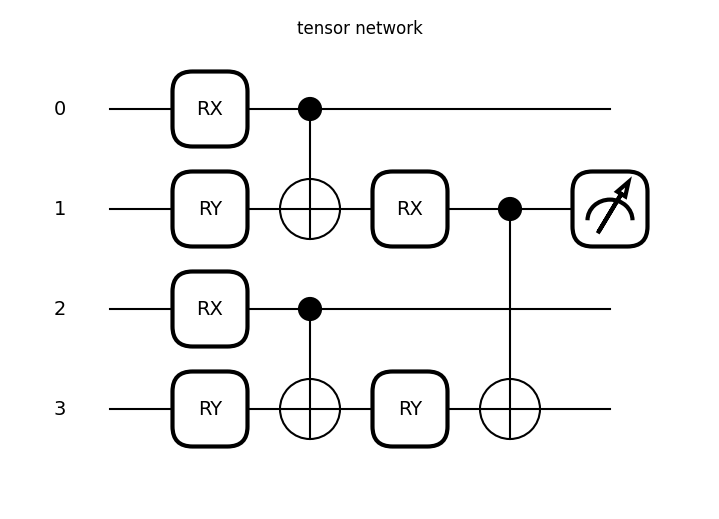

In [25]:
np.random.seed(42)
weights = np.random.uniform(0,np.pi,(3,2),requires_grad = True)
optimiser = qml.GradientDescentOptimizer(stepsize=0.2)
fig,ax = qml.draw_mpl(tensor_network,level=2)(weights)
fig.suptitle('tensor network')
plt.show()

In [26]:
for i in range(30):
    weights,cost = optimiser.step_and_cost(tensor_network,weights)
print(f'final weights is {weights}')
print(f'final expectation value is {tensor_network(weights)}')

final weights is [[1.97658998e-03 3.14124025e+00]
 [2.29962679e+00 1.88074110e+00]
 [1.06614126e-03 4.90071239e-01]]
final expectation value is -0.9999974161267409
